# EfficientNetB4 -- IQ-OTH/NCCD (224x224, 35 epochs, 100% fine-tuning)
Same data pipeline as before: images pooled from the attached Kaggle mirror of the IQ-OTH/NCCD dataset (`Normal cases` / `Bengin cases` / `Malignant cases` folders, auto-detected under `/kaggle/input`), shuffled, and re-split stratified **60% train / 20% validation / 20% test** (`random_state=42`). 3 classes: normal, benign, malignant.

**Specifications for this run:**
- Image size: **224x224**
- Epochs: **25**
- Optimizer: **Adam, learning_rate=5e-4**
- Early stopping: **patience 5** (monitors `val_loss`, restores best weights)
- **100% fine-tuning** -- entire EfficientNetB4 backbone trainable from epoch 1
- **No data augmentation** and **no class weighting** -- plain EfficientNet preprocessing on all three splits, and every sample contributes equally to the loss

**Note:** make sure the IQ-OTH/NCCD Kaggle dataset is attached to this notebook (Add Data) before running -- cell 0 will show it under `/kaggle/input` if it's attached correctly.

## 0. Explore /kaggle/input

In [10]:
import os

max_depth = 4
base_depth = "/kaggle/input".count(os.sep)
for dirpath, dirnames, filenames in os.walk("/kaggle/input"):
    depth = dirpath.count(os.sep) - base_depth
    if depth > max_depth:
        dirnames[:] = []
        continue
    indent = "  " * depth
    print(f"{indent}{os.path.basename(dirpath) or dirpath}/  [{len(filenames)} files]  {filenames[:2]}")

input/  [0 files]  []
  datasets/  [0 files]  []
    hamdallak/  [0 files]  []
      the-iqothnccd-lung-cancer-dataset/  [0 files]  []
        The IQ-OTHNCCD lung cancer dataset/  [1 files]  ['IQ-OTH_NCCD lung cancer dataset.txt']


## 1. Imports

In [11]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

TARGET_CLASSES = ["normal", "benign", "malignant"]
CLASS_TO_IDX = {c: i for i, c in enumerate(TARGET_CLASSES)}
NUM_CLASSES = len(TARGET_CLASSES)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 25
LEARNING_RATE = 5e-4
EARLY_STOP_PATIENCE = 5

## 2. Locate the IQ-OTH/NCCD dataset + build a dataframe

In [12]:
def fuzzy_map_class(folder_name):
    n = folder_name.lower()
    if "normal" in n:
        return "normal"
    if "benign" in n or "bengin" in n:
        return "benign"
    if "malignant" in n:
        return "malignant"
    return None

records = []
found_dirs = []
for dirpath, dirnames, filenames in os.walk("/kaggle/input"):
    label = fuzzy_map_class(os.path.basename(dirpath))
    if label is None:
        continue
    image_files = [f for f in filenames if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))]
    if not image_files:
        continue
    found_dirs.append((dirpath, label, len(image_files)))
    for fname in image_files:
        records.append({"filepath": os.path.join(dirpath, fname), "label": label})

print("Matched folders:")
for d, l, n in found_dirs:
    print(f"  {d}  ->  {l}  ({n} images)")

full_pool = pd.DataFrame(records)
assert len(full_pool) > 0, "No images found -- make sure the IQ-OTH/NCCD dataset is attached under /kaggle/input"

print("\nPooled total:", len(full_pool))
print(full_pool["label"].value_counts())

Matched folders:
  /kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases  ->  normal  (416 images)
  /kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Bengin cases  ->  benign  (120 images)
  /kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Malignant cases  ->  malignant  (561 images)

Pooled total: 1097
label
malignant    561
normal       416
benign       120
Name: count, dtype: int64


## 3. Shuffle + stratified 60/20/20 split

In [13]:
full_pool = full_pool.sample(frac=1.0, random_state=42).reset_index(drop=True)

train_df, temp_df = train_test_split(
    full_pool, train_size=0.60, stratify=full_pool["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, train_size=0.50, stratify=temp_df["label"], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df), " Val size:", len(val_df), " Test size:", len(test_df))
print("\nTrain class balance:\n", train_df["label"].value_counts())
print("\nVal class balance:\n", val_df["label"].value_counts())
print("\nTest class balance:\n", test_df["label"].value_counts())

Train size: 658  Val size: 219  Test size: 220

Train class balance:
 label
malignant    336
normal       250
benign        72
Name: count, dtype: int64

Val class balance:
 label
malignant    112
normal        83
benign        24
Name: count, dtype: int64

Test class balance:
 label
malignant    113
normal        83
benign        24
Name: count, dtype: int64


## 4. Data generators -- no augmentation, plain EfficientNet preprocessing for all splits

In [14]:
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = datagen.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, class_mode="categorical",
    classes=TARGET_CLASSES, batch_size=BATCH_SIZE, shuffle=True, seed=42
)
val_gen = datagen.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, class_mode="categorical",
    classes=TARGET_CLASSES, batch_size=BATCH_SIZE, shuffle=False
)
test_gen = datagen.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, class_mode="categorical",
    classes=TARGET_CLASSES, batch_size=BATCH_SIZE, shuffle=False
)
print("class_indices:", train_gen.class_indices)

Found 658 validated image filenames belonging to 3 classes.
Found 219 validated image filenames belonging to 3 classes.
Found 220 validated image filenames belonging to 3 classes.
class_indices: {'normal': 0, 'benign': 1, 'malignant': 2}


## 5. Model -- EfficientNetB4, 100% trainable from the start

In [15]:
base_model = EfficientNetB4(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3),
    pooling="avg"
)
base_model.trainable = True  # 100% fine-tuning -- entire backbone trainable from epoch 1

output_layer = Dense(NUM_CLASSES, activation="softmax")(base_model.output)
model = Model(inputs=base_model.input, outputs=output_layer)
model.summary()

model.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=LEARNING_RATE),
    metrics=["accuracy"]
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      1,152 │ block1a_se_excit

 Total params: 17,679,202 (67.44 MB)

 Trainable params: 17,553,995 (66.96 MB)

 Non-trainable params: 125,207 (489.09 KB)

## 6. FLOPs -- cost of fine-tuning (image-wise and batch-wise)
Computes actual FLOPs (floating point operations) for this exact model at 224x224, using TensorFlow's graph profiler -- not a lookup-table estimate, but a real trace of `model`'s ops.

**Forward pass** is measured directly. **Training FLOPs (this fine-tuning run)** are then estimated as forward + backward, using the standard `~3x forward FLOPs` approximation (1x forward, ~2x backward). This 3x multiplier applies *here specifically* because `base_model.trainable = True` -- the entire backbone gets gradients, not just a small head.

In [16]:
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph

def get_flops(keras_model, batch_size=1):
    """Forward-pass FLOPs for `keras_model` at the given batch size, via TF's graph profiler."""
    input_shape = [batch_size] + list(keras_model.input.shape[1:])
    concrete_func = tf.function(lambda x: keras_model(x)).get_concrete_function(
        tf.TensorSpec(input_shape, keras_model.input.dtype)
    )
    frozen_func, graph_def = convert_variables_to_constants_v2_as_graph(concrete_func)
    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name="")
        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        flops = tf.compat.v1.profiler.profile(graph=graph, run_meta=run_meta, cmd="op", options=opts)
    return flops.total_float_ops

TRAINING_FLOPS_MULTIPLIER = 3  # forward (1x) + backward (~2x), valid since 100% of the backbone is trainable

# --- Forward pass ---
flops_per_image_fwd = get_flops(model, batch_size=1)
flops_per_batch_fwd = get_flops(model, batch_size=BATCH_SIZE)

# --- Fine-tuning (forward + backward) ---
flops_per_image_train = flops_per_image_fwd * TRAINING_FLOPS_MULTIPLIER
flops_per_batch_train = flops_per_batch_fwd * TRAINING_FLOPS_MULTIPLIER

steps_per_epoch = len(train_df) // BATCH_SIZE
flops_per_epoch_train = flops_per_batch_train * steps_per_epoch
flops_full_run_train = flops_per_epoch_train * EPOCHS  # upper bound -- ignores early stopping cutting epochs short

print("=== Forward pass ===")
print(f"Per image:  {flops_per_image_fwd:,} FLOPs  (~{flops_per_image_fwd/1e9:.3f} GFLOPs)")
print(f"Per batch (batch_size={BATCH_SIZE}):  {flops_per_batch_fwd:,} FLOPs  (~{flops_per_batch_fwd/1e9:.3f} GFLOPs)")

print("\n=== Fine-tuning (forward + backward, ~3x forward) ===")
print(f"Per image:  {flops_per_image_train:,} FLOPs  (~{flops_per_image_train/1e9:.3f} GFLOPs)")
print(f"Per batch (batch_size={BATCH_SIZE}):  {flops_per_batch_train:,} FLOPs  (~{flops_per_batch_train/1e9:.3f} GFLOPs)")
print(f"\nSteps per epoch: {steps_per_epoch}  (train set size {len(train_df)} / batch size {BATCH_SIZE})")
print(f"Per epoch:  {flops_per_epoch_train:,} FLOPs  (~{flops_per_epoch_train/1e12:.3f} TFLOPs)")
print(f"Full {EPOCHS}-epoch run (upper bound, no early stopping):  {flops_full_run_train:,} FLOPs  (~{flops_full_run_train/1e15:.3f} PFLOPs)")

I0000 00:00:1789928804.993518      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1789928804.993719      58 single_machine.cc:376] Starting new session
I0000 00:00:1789928805.008959      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789928805.010612      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

I0000 00:00:1789928813.449942      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1789928813.450137      58 single_machine.cc:376] Starting new session
I0000 00:00:1789928813.465342      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789928813.467001      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

## 7. Callbacks

In [17]:
callbacks = [
    ModelCheckpoint("best_effnetb4_iqothnccd_224.keras", monitor="val_accuracy", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_loss", patience=EARLY_STOP_PATIENCE, restore_best_weights=True, verbose=1),
]

## 8. Fine-tune (100% -- entire backbone trainable)

In [18]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/25
37/42 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.7636 - loss: 0.5569

2026-09-20 18:29:39.754919: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:29:39.888318: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:29:40.121566: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:29:40.256063: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:29:40.493899: E external/local_xla/xla/stream_

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7728 - loss: 0.5377

2026-09-20 18:30:50.366463: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:30:50.500232: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:30:50.731287: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:30:50.868829: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:30:51.118659: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from None to 0.64840, saving model to best_effnetb4_iqothnccd_224.keras

Epoch 1: finished saving model to best_effnetb4_iqothnccd_224.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 242s 3s/step - accuracy: 0.8450 - loss: 0.3902 - val_accuracy: 0.6484 - val_loss: 1.1949
Epoch 2/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9440 - loss: 0.2021
Epoch 2: val_accuracy improved from 0.64840 to 0.89498, saving model to best_effnetb4_iqothnccd_224.keras

Epoch 2: finished saving model to best_effnetb4_iqothnccd_224.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 13s 304ms/step - accuracy: 0.9483 - loss: 0.1740 - val_accuracy: 0.8950 - val_loss: 0.2183
Epoch 3/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9426 - loss: 0.1737
Epoch 3: val_accuracy improved from 0.89498 to 0.91781, saving model to best_effnetb4_iqothnccd_224.keras

Epoch 3: finished saving model to best_effnetb4_iqothnccd_224.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 262ms/step - accuracy: 0.9347 - loss: 0.

## 9. Plot train/val loss + accuracy

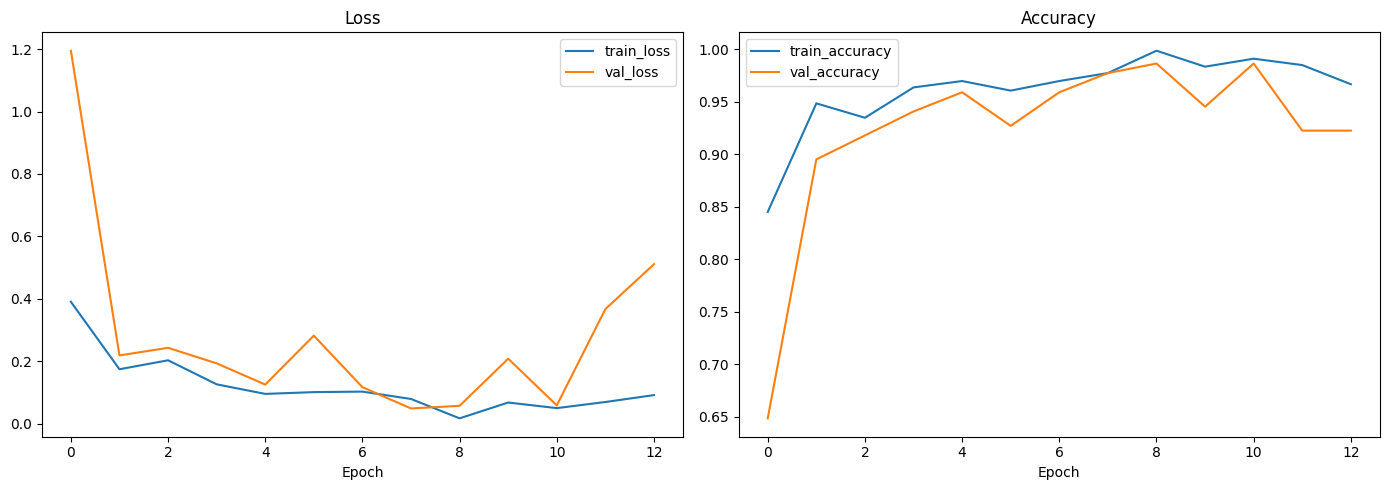

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="train_loss")
axes[0].plot(history.history["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train_accuracy")
axes[1].plot(history.history["val_accuracy"], label="val_accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves_effnetb4_iqothnccd_224.png", dpi=150)
plt.show()

## 10. Final evaluation on TEST set

13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 1.0000 - loss: 0.0122

2026-09-20 18:33:31.737786: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:33:31.871877: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:33:32.106753: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:33:32.244905: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:33:32.494038: E external/local_xla/xla/stream_

14/14 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.9955 - loss: 0.0535 
Test loss: 0.0535  Test accuracy: 0.9955

Classification Report:
              precision    recall  f1-score   support

      normal     1.0000    0.9880    0.9939        83
      benign     0.9600    1.0000    0.9796        24
   malignant     1.0000    1.0000    1.0000       113

    accuracy                         0.9955       220
   macro avg     0.9867    0.9960    0.9912       220
weighted avg     0.9956    0.9955    0.9955       220

Test macro F1: 0.9912

Prediction distribution:
malignant    113
normal        82
benign        25
Name: count, dtype: int64


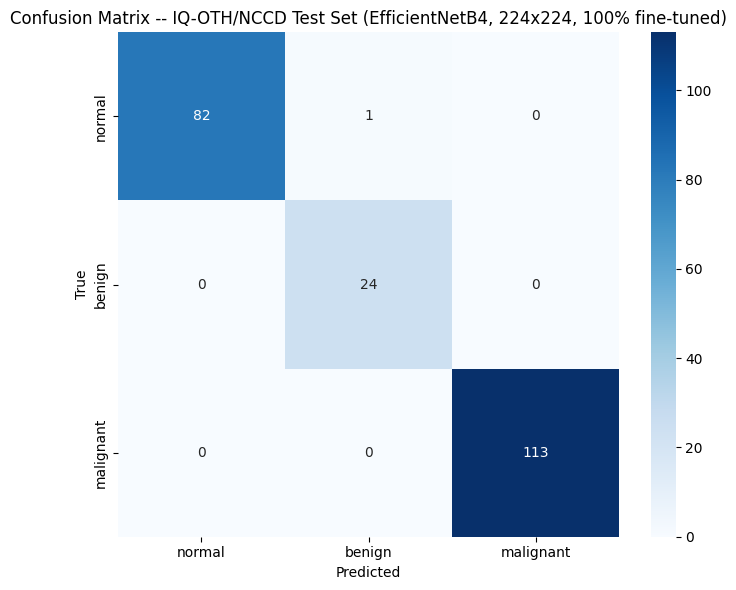


EfficientNetB4 (IQ-OTH/NCCD, 224x224) test accuracy: 99.55%


In [20]:
best_model = tf.keras.models.load_model("best_effnetb4_iqothnccd_224.keras")

test_gen.reset()
test_loss, test_acc = best_model.evaluate(test_gen, verbose=1)
print(f"Test loss: {test_loss:.4f}  Test accuracy: {test_acc:.4f}")

test_gen.reset()
y_pred_probs = best_model.predict(test_gen, verbose=0)
y_pred_idx = np.argmax(y_pred_probs, axis=1)
y_true_idx = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true_idx, y_pred_idx, target_names=TARGET_CLASSES, digits=4))

test_macro_f1 = f1_score(y_true_idx, y_pred_idx, average="macro")
print(f"Test macro F1: {test_macro_f1:.4f}")

print("\nPrediction distribution:")
print(pd.Series(y_pred_idx).map({i: c for i, c in enumerate(TARGET_CLASSES)}).value_counts())

cm = confusion_matrix(y_true_idx, y_pred_idx)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix -- IQ-OTH/NCCD Test Set (EfficientNetB4, 224x224, 100% fine-tuned)")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_effnetb4_iqothnccd_224.png", dpi=150)
plt.show()

print(f"\nEfficientNetB4 (IQ-OTH/NCCD, 224x224) test accuracy: {test_acc*100:.2f}%")

In [21]:
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph

def get_flops(keras_model, batch_size=1):
    """Forward-pass FLOPs for `keras_model` at the given batch size, via TF's graph profiler."""
    input_shape = [batch_size] + list(keras_model.input.shape[1:])
    concrete_func = tf.function(lambda x: keras_model(x)).get_concrete_function(
        tf.TensorSpec(input_shape, keras_model.input.dtype)
    )
    frozen_func, graph_def = convert_variables_to_constants_v2_as_graph(concrete_func)
    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name="")
        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        flops = tf.compat.v1.profiler.profile(graph=graph, run_meta=run_meta, cmd="op", options=opts)
    return flops.total_float_ops

# --- Trainable-vs-frozen split, read directly off the model (handles "100% fine-tuning" automatically) ---
trainable_param_count = sum(int(tf.size(w)) for w in model.trainable_weights)
total_param_count = sum(int(tf.size(w)) for w in model.weights)
trainable_fraction = trainable_param_count / total_param_count   # 1.0 here, since base_model.trainable = True

BACKWARD_MULTIPLIER = 2 * trainable_fraction   # backward pass cost, scaled by how much is actually trainable
TOTAL_MULTIPLIER = 1 + BACKWARD_MULTIPLIER      # forward (always 1x) + backward

print(f"Trainable params: {trainable_param_count:,} / {total_param_count:,}  (trainable_fraction={trainable_fraction:.4f})")

# --- FORWARD pass FLOPs ---
flops_per_image_fwd = get_flops(model, batch_size=1)
flops_per_batch_fwd = get_flops(model, batch_size=BATCH_SIZE)

# --- BACKWARD pass FLOPs (derived, not separately traced -- backward isn't directly profilable the same way) ---
flops_per_image_bwd = flops_per_image_fwd * BACKWARD_MULTIPLIER
flops_per_batch_bwd = flops_per_batch_fwd * BACKWARD_MULTIPLIER

# --- TOTAL training FLOPs (forward + backward) ---
flops_per_image_total = flops_per_image_fwd * TOTAL_MULTIPLIER
flops_per_batch_total = flops_per_batch_fwd * TOTAL_MULTIPLIER

steps_per_epoch = len(train_df) // BATCH_SIZE
flops_per_epoch_total = flops_per_batch_total * steps_per_epoch
flops_full_run_total = flops_per_epoch_total * EPOCHS  # upper bound -- ignores early stopping

print("\n=== FORWARD ===")
print(f"Per image:  {flops_per_image_fwd:,}  (~{flops_per_image_fwd/1e9:.3f} GFLOPs)")
print(f"Per batch:  {flops_per_batch_fwd:,}  (~{flops_per_batch_fwd/1e9:.3f} GFLOPs)")

print("\n=== BACKWARD ===")
print(f"Per image:  {flops_per_image_bwd:,.0f}  (~{flops_per_image_bwd/1e9:.3f} GFLOPs)")
print(f"Per batch:  {flops_per_batch_bwd:,.0f}  (~{flops_per_batch_bwd/1e9:.3f} GFLOPs)")

print("\n=== TOTAL (forward + backward) ===")
print(f"Per image:  {flops_per_image_total:,.0f}  (~{flops_per_image_total/1e9:.3f} GFLOPs)")
print(f"Per batch:  {flops_per_batch_total:,.0f}  (~{flops_per_batch_total/1e9:.3f} GFLOPs)")
print(f"Per epoch:  {flops_per_epoch_total:,.0f}  (~{flops_per_epoch_total/1e12:.3f} TFLOPs)  [{steps_per_epoch} steps/epoch]")
print(f"Full {EPOCHS}-epoch run (upper bound, no early stopping):  {flops_full_run_total:,.0f}  (~{flops_full_run_total/1e15:.3f} PFLOPs)")

Trainable params: 17,553,995 / 17,679,202  (trainable_fraction=0.9929)


I0000 00:00:1789929500.609066      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1789929500.609243      58 single_machine.cc:376] Starting new session
I0000 00:00:1789929500.624797      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789929500.626513      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

I0000 00:00:1789929508.907032      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1789929508.907205      58 single_machine.cc:376] Starting new session
I0000 00:00:1789929508.922401      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789929508.924077      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th